# Clash of Clans ML Lab - Problem 3: Clan War Performance Regression

**Objective:** Predict historical clan war performance using **only structural, compositional, infrastructure, and player progression features**.

**Target:** `war_success_rate` (continuous, bounded [0,1])

**Leakage prevention:** Strictly exclude direct war outcome accumulators (`war_wins`, `war_losses`, `war_ties`, `war_win_streak`) from predictor features X.

## 1. Setup & Dynamic Environment

In [32]:
from pathlib import Path
import sys
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.figsize'] = (12, 6)

def find_project_root(marker: str = 'data') -> Path:
    """Locate the project root by searching upwards for a directory named `marker`."""
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    return current

root = find_project_root()
dataset_path = root / 'data' / 'datasets' / 'clan_war_performance_regression.parquet'
df = pd.read_parquet(dataset_path)

print(f'Project root: {root}')
print(f'Dataset path: {dataset_path}')
print(f'Initial shape: {df.shape}')
print(f'Columns: {list(df.columns)}')

Project root: C:\Users\Usuario\Desktop\Clash of Clans ML Lab
Dataset path: C:\Users\Usuario\Desktop\Clash of Clans ML Lab\data\datasets\clan_war_performance_regression.parquet
Initial shape: (31289, 51)
Columns: ['clan_tag', 'clan_level', 'clan_points', 'clan_capital_points', 'members', 'required_trophies', 'war_frequency', 'war_league', 'capital_league', 'type', 'is_family_friendly', 'location_id', 'location_name', 'mean_town_hall_level', 'median_town_hall_level', 'std_town_hall_level', 'mean_exp_level', 'median_exp_level', 'std_exp_level', 'mean_trophies', 'median_trophies', 'std_trophies', 'mean_donations', 'median_donations', 'std_donations', 'mean_donations_received', 'median_donations_received', 'std_donations_received', 'mean_clan_capital_contributions', 'median_clan_capital_contributions', 'std_clan_capital_contributions', 'mean_troop_mean_level', 'mean_troop_mean_completion_ratio', 'mean_hero_mean_level', 'mean_hero_mean_completion_ratio', 'mean_spell_mean_level', 'mean_spell_

## 2. Data Integrity & Leakage Prevention Audit

In [33]:
# Dimensions, dtypes, missing values, duplicates
print('--- DataFrame info ---')
df.info(verbose=True, show_counts=True)
print('\n--- Missing values ---')
print(df.isna().sum())
print('\n--- Duplicate rows ---')
print(f'Duplicated rows: {df.duplicated().sum()}')

--- DataFrame info ---
<class 'pandas.DataFrame'>
RangeIndex: 31289 entries, 0 to 31288
Data columns (total 51 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   clan_tag                              31289 non-null  str    
 1   clan_level                            31289 non-null  int64  
 2   clan_points                           31289 non-null  int64  
 3   clan_capital_points                   31289 non-null  int64  
 4   members                               31289 non-null  int64  
 5   required_trophies                     31289 non-null  int64  
 6   war_frequency                         31289 non-null  str    
 7   war_league                            31289 non-null  str    
 8   capital_league                        31289 non-null  str    
 9   type                                  31289 non-null  str    
 10  is_family_friendly                    31289 non-null  bool   
 11  loc

In [34]:
# Leakage prevention: direct war history columns must be removed from predictors.
TARGET = 'war_success_rate'
LEAKED_COLS = ['war_wins', 'war_losses', 'war_ties', 'war_win_streak']

leaked_present = [col for col in LEAKED_COLS if col in df.columns]
print(f'Leaked columns present in dataset: {leaked_present}')

if leaked_present:
    print('Dropping leaked columns from feature matrix X.')
    X = df.drop(columns=[TARGET] + leaked_present)
else:
    print('No direct leaked columns found. Proceeding with all non-target columns.')
    X = df.drop(columns=[TARGET])

y = df[TARGET].copy()
print(f'\nX shape after leakage removal: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Any remaining leaked columns in X? {any(col in X.columns for col in LEAKED_COLS)}')

Leaked columns present in dataset: []
No direct leaked columns found. Proceeding with all non-target columns.

X shape after leakage removal: (31289, 50)
y shape: (31289,)
Any remaining leaked columns in X? False


In [35]:
# Quasi-constant / zero-variance detection (mode frequency >= 95%)
def mode_frequency(series):
    if series.nunique(dropna=True) == 0:
        return 1.0
    if series.nunique(dropna=True) == 1:
        return 1.0
    value_counts = series.value_counts(dropna=True, normalize=True)
    return value_counts.iloc[0] if len(value_counts) > 0 else 1.0

quasi_const_cols = []
for col in X.columns:
    freq = mode_frequency(X[col])
    if freq >= 0.95:
        quasi_const_cols.append((col, freq))

print(f'Quasi-constant columns (mode frequency >= 95%): {len(quasi_const_cols)}')
for col, freq in quasi_const_cols:
    print(f'  {col}: {freq:.4f}')

Quasi-constant columns (mode frequency >= 95%): 0


## 3. Target Analysis (`war_success_rate`)

In [36]:
target = y
desc = target.describe(percentiles=[.25, .5, .75])
skew = target.skew()
kurt = target.kurtosis()
iqr = desc.loc['75%'] - desc.loc['25%']

print('--- Descriptive statistics for war_success_rate ---')
print(desc)
print(f'\nSkewness: {skew:.4f}')
print(f'Kurtosis: {kurt:.4f}')
print(f'IQR: {iqr:.4f}')
print(f'Min: {desc.loc["min"]:.4f}')
print(f'Max: {desc.loc["max"]:.4f}')

--- Descriptive statistics for war_success_rate ---
count    31289.000000
mean         0.509337
std          0.141786
min          0.000000
25%          0.419753
50%          0.514073
75%          0.603774
max          1.000000
Name: war_success_rate, dtype: float64

Skewness: -0.2072
Kurtosis: 0.2714
IQR: 0.1840
Min: 0.0000
Max: 1.0000


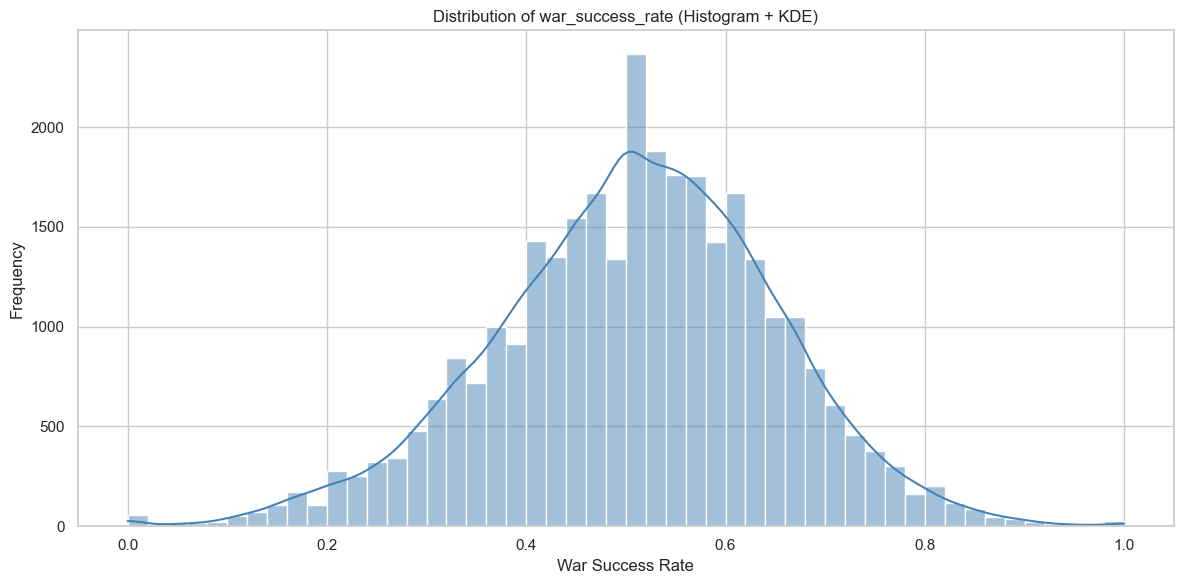

In [37]:
plt.figure(figsize=(12, 6))
sns.histplot(target, kde=True, bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of war_success_rate (Histogram + KDE)')
plt.xlabel('War Success Rate')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Target distribution properties and modeling implications

- The target is bounded in [0, 1]. If values accumulate near 0 or 1, the distribution may be skewed or inflated at the extremes.
- **Skewness** and **kurtosis** help decide whether a transform (e.g., logit) or a beta regression is appropriate.
- For standard regression, consider:
  - Using `MinMaxScaler` to keep predictions within [0,1] if using models that do not enforce range (e.g., linear models).
  - Applying a **logit transform** `ln(y / (1-y))` only if no exact 0/1 values exist, otherwise use an epsilon clipping.
  - Using loss functions robust to bounded targets: **Huber loss**, **quantile loss**, or **beta regression**.
- If the distribution is approximately normal, **MSE/RMSE** are natural choices.

## 4. Feature Group Profiling

In [38]:
# === 4. Feature Group Profiling ===

# Define feature groups based on column naming patterns
feature_groups = {
    'Town Hall & Composition': ['TH', 'townhall', 'th'],
    'Player Progression': ['EXP', 'hero_level', 'troop_progress', 'spell_progress', 'equipment_progress', 'war_stars'],
    'Infrastructure & Activity': ['clan_level', 'member_count', 'donation_rate', 'capital_contribution_rate', 'clan_capital_points', 'clan_points', 'league', 'location']
}

def assign_group(col: str) -> str:
    col_lower = col.lower()
    for group, patterns in feature_groups.items():
        for pat in patterns:
            if pat.lower() in col_lower:
                return group
    return 'Other'

# Map each column in X to its respective group
group_assignments = {col: assign_group(col) for col in X.columns}

# Print explicit mapping per group
print('=== Feature Group Assignments ===')
for group in list(feature_groups.keys()) + ['Other']:
    cols = [col for col, g in group_assignments.items() if g == group]
    if cols:
        print(f'\n{group} ({len(cols)} columns):')
        for c in cols:
            print(f'  - {c}')

# Calculate group-level summary metrics (Missing %, Zero %, Skewness)
metrics_list = []
for col in X.columns:
    col_data = X[col]
    is_num = pd.api.types.is_numeric_dtype(col_data)
    
    missing_pct = col_data.isna().mean() * 100
    zero_pct = (col_data == 0).mean() * 100 if is_num else np.nan
    skew_val = stats.skew(col_data.dropna()) if is_num else np.nan
    
    metrics_list.append({
        'feature': col,
        'group': group_assignments[col],
        'missing_pct': missing_pct,
        'zero_pct': zero_pct,
        'skewness': skew_val
    })

df_feature_metrics = pd.DataFrame(metrics_list)

print('\n=== Feature Group Summary Statistics ===')
group_summary = df_feature_metrics.groupby('group').agg(
    feature_count=('feature', 'count'),
    avg_missing_pct=('missing_pct', 'mean'),
    avg_zero_pct=('zero_pct', 'mean'),
    avg_abs_skewness=('skewness', lambda x: x.abs().mean())
).reset_index()

display(group_summary)

=== Feature Group Assignments ===

Town Hall & Composition (2 columns):
  - th18_percentage
  - th17_plus_percentage

Player Progression (3 columns):
  - mean_exp_level
  - median_exp_level
  - std_exp_level

Infrastructure & Activity (10 columns):
  - clan_level
  - clan_points
  - clan_capital_points
  - war_league
  - capital_league
  - location_id
  - location_name
  - member_count
  - donation_rate
  - capital_contribution_rate

Other (35 columns):
  - clan_tag
  - members
  - required_trophies
  - war_frequency
  - type
  - is_family_friendly
  - mean_town_hall_level
  - median_town_hall_level
  - std_town_hall_level
  - mean_trophies
  - median_trophies
  - std_trophies
  - mean_donations
  - median_donations
  - std_donations
  - mean_donations_received
  - median_donations_received
  - std_donations_received
  - mean_clan_capital_contributions
  - median_clan_capital_contributions
  - std_clan_capital_contributions
  - mean_troop_mean_level
  - mean_troop_mean_completion_ratio

,group,feature_count,avg_missing_pct,avg_zero_pct,avg_abs_skewness
0,Infrastructure & Activity,10,0.0,17.275355,10.593682
1,Other,35,0.0,27.302427,22.269449
2,Player Progression,3,0.0,0.584870,0.271462
3,Town Hall & Composition,2,0.0,60.075426,2.342364


In [39]:
profile_rows = []
for group in feature_groups.keys():
    cols = [col for col, g in group_assignments.items() if g == group]
    if not cols:
        continue
    for col in cols:
        series = X[col]
        profile_rows.append({
            'group': group,
            'feature': col,
            'dtype': str(series.dtype),
            'missing_pct': round(series.isna().mean() * 100, 2),
            'zero_pct': round((series == 0).mean() * 100, 2),
            'skewness': round(series.skew(), 3) if series.dtype in ['float64','int64'] else np.nan
        })

profile_df = pd.DataFrame(profile_rows).sort_values(['group', 'feature'])
print('--- Feature group profiling ---')
display(profile_df)  # works in Jupyter; fallback to print if needed
# If display not available, use print(profile_df.to_string())

--- Feature group profiling ---


,group,feature,dtype,missing_pct,zero_pct,skewness
14,Infrastructure & Activity,capital_contribution_rate,float64,0.0,6.08,2.086
9,Infrastructure & Activity,capital_league,str,0.0,0.00,NaN
7,Infrastructure & Activity,clan_capital_points,int64,0.0,45.92,1.972
5,Infrastructure & Activity,clan_level,int64,0.0,0.00,0.891
6,Infrastructure & Activity,clan_points,int64,0.0,16.66,2.976
13,Infrastructure & Activity,donation_rate,float64,0.0,50.41,58.080
10,Infrastructure & Activity,location_id,float64,0.0,1.86,-7.120
11,Infrastructure & Activity,location_name,str,0.0,0.00,NaN
12,Infrastructure & Activity,member_count,int64,0.0,0.00,1.035
8,Infrastructure & Activity,war_league,str,0.0,0.00,NaN


## 5. Feature-Target Relationships (Regression)

In [ ]:
# Mutual Information with safe handling of categorical features, non-finite, and missing values.
def safe_mutual_info(X, y, random_state=42):
    X_clean = X.replace([np.inf, -np.inf], np.nan).copy()
    X_processed = pd.DataFrame(index=X_clean.index)
    
    for col in X_clean.columns:
        # 1. Drop 100% empty columns
        if X_clean[col].isna().all():
            print(f'Dropped column {col}: all values missing.')
            continue
            
        # 2. Drop identifiers or high-cardinality string columns (clan tags, IDs)
        if col.lower() in ['tag', 'clan_tag', 'id', 'name'] or (X_clean[col].dtype == 'object' and X_clean[col].nunique() > 0.8 * len(X_clean)):
            print(f'Dropped identifier/string column from MI: {col}')
            continue

        # 3. Process numerical columns
        if pd.api.types.is_numeric_dtype(X_clean[col]):
            med = X_clean[col].median()
            X_processed[col] = X_clean[col].fillna(med if pd.notna(med) else 0)
        # 4. Process categorical variables (factorize to integers)
        else:
            cats, _ = pd.factorize(X_clean[col].astype(str).fillna('MISSING'))
            X_processed[col] = cats

    mi = mutual_info_regression(X_processed, y, random_state=random_state)
    mi_series = pd.Series(mi, index=X_processed.columns, name='MI')
    return mi_series.sort_values(ascending=False)

mi_series = safe_mutual_info(X, y)
print('--- Mutual Information (top 10) ---')
print(mi_series.head(10).to_string())

Dropped identifier/string column from MI: clan_tag
--- Mutual Information (top 10) ---
clan_level                           0.360190
war_league                           0.181768
median_town_hall_level               0.089605
location_name                        0.079903
mean_achievement_completion_ratio    0.074440
sum_clan_capital_contributions       0.072286
median_clan_capital_contributions    0.070231
capital_league                       0.070110
capital_contribution_rate            0.069072
mean_clan_capital_contributions      0.068808


In [ ]:
# Filter numeric columns only to prevent errors with string/text variables (tags, names, etc.)
X_num = X.select_dtypes(include=[np.number])

# Pearson and Spearman correlations with the target
pearson_corr = X_num.corrwith(y, method='pearson').sort_values(ascending=False)
spearman_corr = X_num.corrwith(y, method='spearman').sort_values(ascending=False)

print('--- Top 10 Pearson ---')
print(pearson_corr.head(10).to_string())
print('\n--- Top 10 Spearman ---')
print(spearman_corr.head(10).to_string())

--- Top 10 Pearson ---
mean_spell_mean_level                   0.248612
mean_spell_mean_completion_ratio        0.246169
clan_level                              0.230274
mean_hero_mean_level                    0.213823
mean_troop_mean_completion_ratio        0.194013
mean_hero_mean_completion_ratio         0.193601
mean_exp_level                          0.191881
mean_equipment_mean_level               0.186440
mean_equipment_mean_completion_ratio    0.182959
mean_troop_mean_level                   0.182113

--- Top 10 Spearman ---
clan_level                           0.265546
mean_spell_mean_level                0.262182
mean_spell_mean_completion_ratio     0.255499
mean_hero_mean_level                 0.222937
mean_achievement_completion_ratio    0.214750
mean_troop_mean_completion_ratio     0.206632
mean_hero_mean_completion_ratio      0.206041
median_clan_capital_contributions    0.201887
mean_exp_level                       0.201856
sum_donations                        0.197532


In [ ]:
# Display combined top tables
mi_top = mi_series.head(10).rename('Mutual Information')
pearson_top = pearson_corr.head(10).rename('Pearson r')
spearman_top = spearman_corr.head(10).rename('Spearman rho')
combined = pd.concat([mi_top, pearson_top, spearman_top], axis=1, join='inner')
print('--- Top feature-target relationship summary (by MI) ---')
display(combined)

--- Top feature-target relationship summary (by MI) ---


,Mutual Information,Pearson r,Spearman rho
clan_level,0.36019,0.230274,0.265546


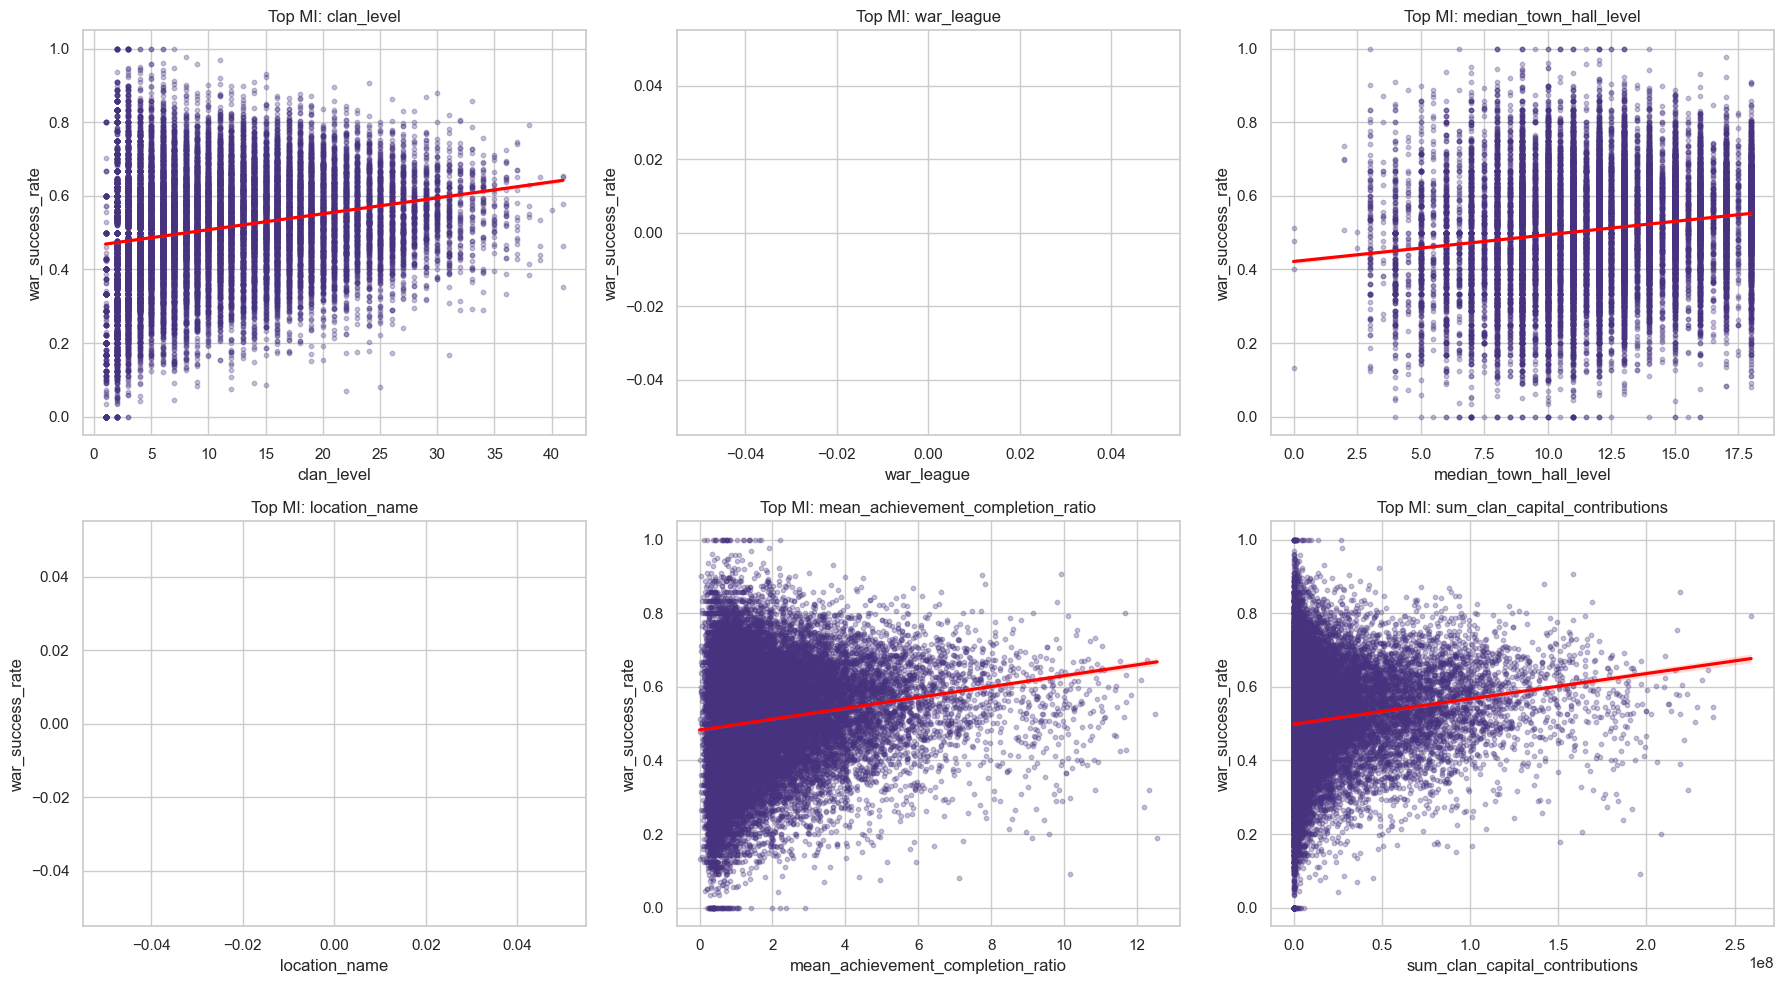

In [ ]:
top_mi_features = mi_series.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_mi_features):
    ax = axes[i]
    
    # Ensure numeric conversion to float64
    x_data = pd.to_numeric(X[col], errors='coerce').astype('float64')
    y_data = pd.to_numeric(y, errors='coerce').astype('float64')
    
    # Filter valid finite values for plotting
    mask = x_data.notna() & y_data.notna() & np.isfinite(x_data) & np.isfinite(y_data)
    
    sns.regplot(
        x=x_data[mask], 
        y=y_data[mask], 
        ax=ax, 
        scatter_kws={'alpha': 0.3, 's': 10}, 
        line_kws={'color': 'red'}
    )
    ax.set_title(f'Top MI: {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('war_success_rate')

# Hide empty subplots if fewer than 6 features exist
for j in range(len(top_mi_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6. Collinearity & Feature Redundancy

In [44]:
# Correlation matrices on predictors
X_numeric = X.select_dtypes(include=[np.number])
pearson_matrix = X_numeric.corr(method='pearson')
spearman_matrix = X_numeric.corr(method='spearman')

print(f'Pearson matrix shape: {pearson_matrix.shape}')
print(f'Spearman matrix shape: {spearman_matrix.shape}')

Pearson matrix shape: (43, 43)
Spearman matrix shape: (43, 43)


In [45]:
def high_corr_pairs(corr_matrix, threshold=0.85):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > threshold:
                pairs.append((cols[i], cols[j], r))
    return pairs

pearson_high = high_corr_pairs(pearson_matrix)
spearman_high = high_corr_pairs(spearman_matrix)

print(f'High Pearson correlation pairs (|r|>0.85): {len(pearson_high)}')
for pair in pearson_high:
    print(f'  {pair[0]} - {pair[1]}: {pair[2]:.3f}')

print(f'\nHigh Spearman correlation pairs (|ρ|>0.85): {len(spearman_high)}')
for pair in spearman_high:
    print(f'  {pair[0]} - {pair[1]}: {pair[2]:.3f}')

High Pearson correlation pairs (|r|>0.85): 112
  clan_points - clan_capital_points: 0.900
  clan_points - sum_clan_capital_contributions: 0.916
  clan_capital_points - sum_clan_capital_contributions: 0.877
  members - member_count: 1.000
  mean_town_hall_level - median_town_hall_level: 0.979
  mean_town_hall_level - mean_exp_level: 0.936
  mean_town_hall_level - median_exp_level: 0.915
  mean_town_hall_level - mean_troop_mean_level: 0.920
  mean_town_hall_level - mean_troop_mean_completion_ratio: 0.926
  mean_town_hall_level - mean_hero_mean_level: 0.930
  mean_town_hall_level - mean_hero_mean_completion_ratio: 0.930
  mean_town_hall_level - mean_spell_mean_level: 0.871
  mean_town_hall_level - mean_spell_mean_completion_ratio: 0.912
  mean_town_hall_level - mean_equipment_mean_level: 0.910
  mean_town_hall_level - mean_equipment_mean_completion_ratio: 0.913
  median_town_hall_level - mean_exp_level: 0.918
  median_town_hall_level - median_exp_level: 0.918
  median_town_hall_level - me

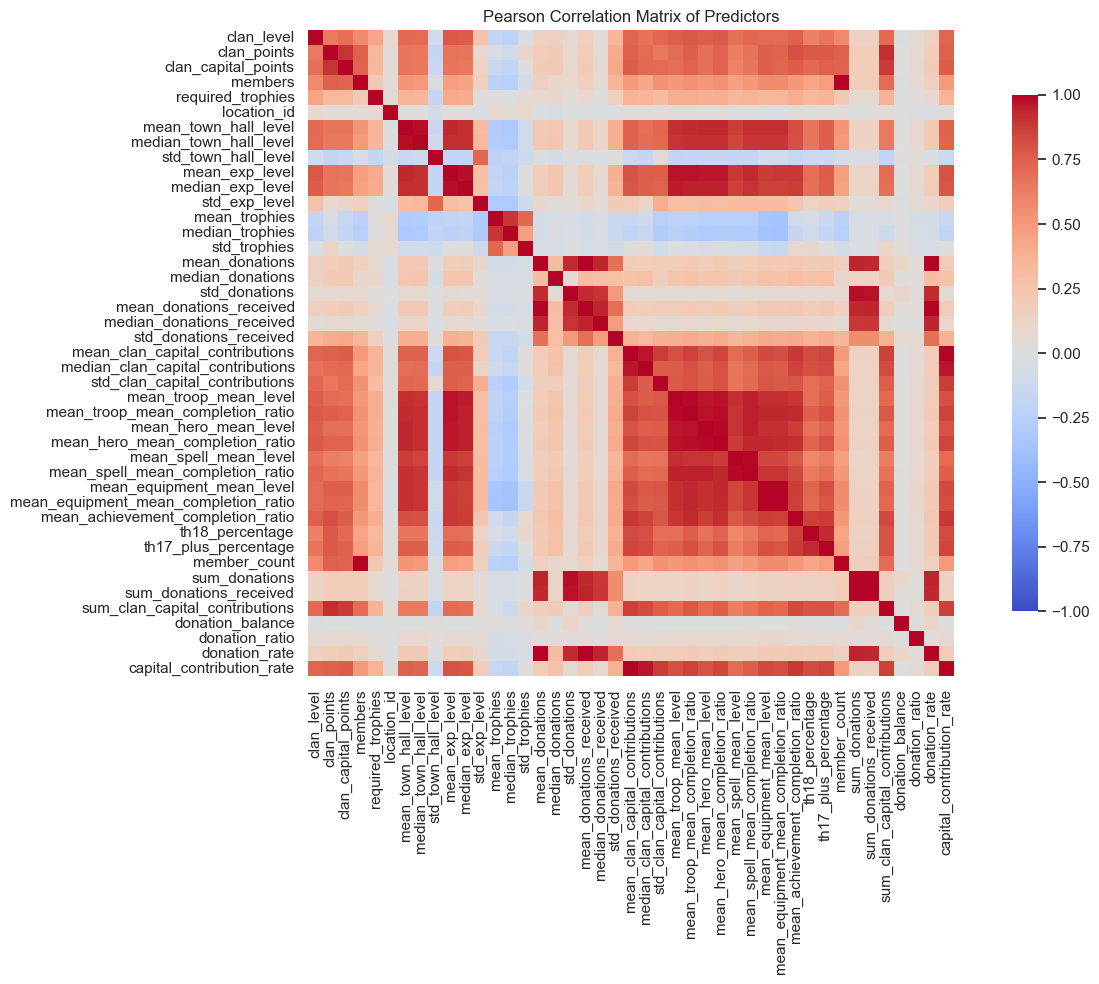

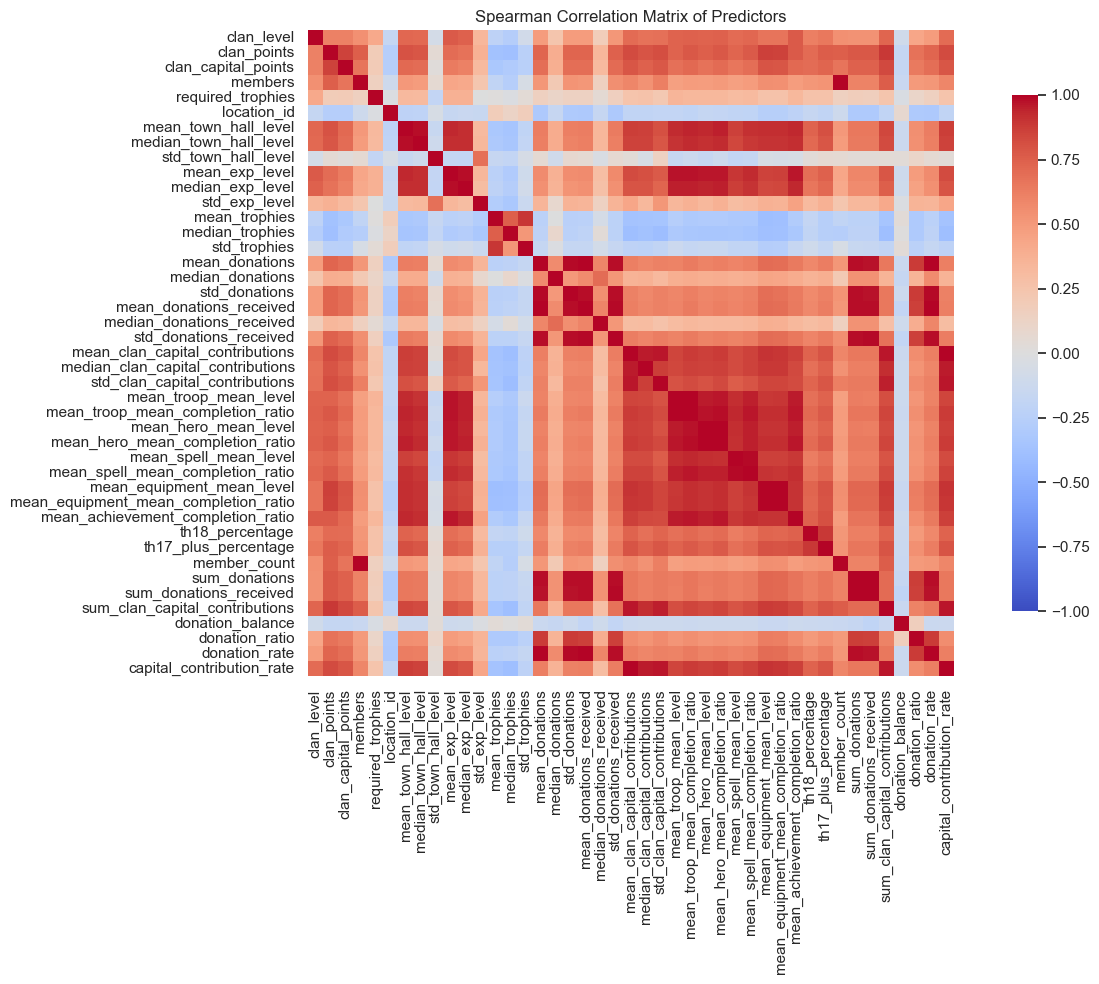

In [46]:
plt.figure(figsize=(14, 10))
sns.heatmap(pearson_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink':0.8})
plt.title('Pearson Correlation Matrix of Predictors')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
sns.heatmap(spearman_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={'shrink':0.8})
plt.title('Spearman Correlation Matrix of Predictors')
plt.tight_layout()
plt.show()

## 7. Outlier & Extreme Case Detection

In [47]:
def iqr_outlier_percentage(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((series < lower) | (series > upper)).mean() * 100

outlier_report = X_numeric.apply(iqr_outlier_percentage).sort_values(ascending=False)
print('--- IQR outlier percentage per feature (top 20) ---')
print(outlier_report.head(20).to_string())

--- IQR outlier percentage per feature (top 20) ---
median_trophies                      18.770175
donation_balance                     18.498514
median_donations_received            15.420755
median_donations                     14.065646
sum_clan_capital_contributions       13.915434
th18_percentage                      13.576656
clan_points                          13.503148
sum_donations                        12.426092
sum_donations_received               12.394132
th17_plus_percentage                 12.074531
median_clan_capital_contributions    11.854006
clan_capital_points                  11.032631
mean_donations_received               9.083064
mean_donations                        9.057496
donation_rate                         9.051104
capital_contribution_rate             8.929656
mean_clan_capital_contributions       8.910480
std_donations_received                8.737895
std_donations                         8.734699
mean_achievement_completion_ratio     5.717664


In [48]:
# Inspect extreme records for selected key features
key_features = ['mean_equipment_progress', 'donation_rate', 'clan_capital_points', 'mean_hero_level']
available_keys = [f for f in key_features if f in X.columns]
print(f'Available key features for extreme inspection: {available_keys}')

for feat in available_keys:
    top_extreme = df.nlargest(10, feat)[[TARGET, feat]]
    print(f'\nTop 10 records for {feat}:')
    print(top_extreme.to_string(index=False))

Available key features for extreme inspection: ['donation_rate', 'clan_capital_points']

Top 10 records for donation_rate:
 war_success_rate  donation_rate
         0.351254   25335.220000
         0.394366   21510.680000
         0.628866   17016.408163
         0.598020   11968.044444
         0.460358    9840.468750
         0.714286    6568.900000
         0.518519    6417.489796
         0.469027    5599.571429
         0.400000    3479.600000
         0.379310    3263.062500

Top 10 records for clan_capital_points:
 war_success_rate  clan_capital_points
         0.578554                 6349
         0.583201                 5733
         0.644340                 5559
         0.668862                 5546
         0.751092                 5520
         0.525547                 5516
         0.724907                 5482
         0.858903                 5479
         0.706667                 5467
         0.488423                 5438


## 8. Modeling Implications & Executive Summary

In [49]:
# Construct an executable summary dictionary of findings and recommendations.
summary = {
    'dataset_shape': df.shape,
    'target': TARGET,
    'leakage_columns_removed': leaked_present,
    'quasi_constant_features': [col for col, _ in quasi_const_cols],
    'target_stats': {
        'mean': desc.loc['mean'],
        'std': desc.loc['std'],
        'median': desc.loc['50%'],
        'IQR': iqr,
        'min': desc.loc['min'],
        'max': desc.loc['max'],
        'skewness': skew,
        'kurtosis': kurt
    },
    'top_MI_features': mi_series.head(10).index.tolist(),
    'high_collinearity_pearson_pairs': [(a,b,round(r,3)) for a,b,r in pearson_high],
    'high_collinearity_spearman_pairs': [(a,b,round(r,3)) for a,b,r in spearman_high],
    'preprocessing_recommendations': [
        'Impute missing values using median for numeric features and most frequent category for categorical features.',
        'Apply log1p transformation to highly skewed positive-valued features to reduce skew.',
        'Use RobustScaler for features with outliers to minimize their influence.',
        'Consider MinMaxScaler if using models sensitive to scale (e.g., SVM).',
        'Remove quasi-constant features (mode frequency >= 95%).',
        'For collinear feature pairs (|r|>0.85), retain the feature with higher Mutual Information.'
    ],
    'cv_strategy': (
        'Use StratifiedKFold on binned target (e.g., deciles) to preserve distribution across folds, '
        'or GroupKFold if there is a group identifier to prevent leakage between related clans.'
    ),
    'evaluation_metrics': ['MAE', 'RMSE', 'R^2'],
    'baseline_models': [
        'Ridge Regression (linear baseline, regularized)',
        'Random Forest Regressor (non-linear, robust to outliers)',
        'XGBoost Regressor (gradient boosting, often strong on tabular data)'
    ],
    'feature_selection_strategy': 'Use Mutual Information to rank features and break ties among collinear pairs.',
}

print('--- Executive Summary ---')
for key, value in summary.items():
    if key in ['preprocessing_recommendations', 'baseline_models']:
        print(f'\n{key}:')
        for item in value:
            print(f'  - {item}')
    else:
        print(f'{key}: {value}')

--- Executive Summary ---
dataset_shape: (31289, 51)
target: war_success_rate
leakage_columns_removed: []
quasi_constant_features: []
target_stats: {'mean': np.float64(0.5093370272973553), 'std': np.float64(0.14178621703460143), 'median': np.float64(0.5140728476821192), 'IQR': np.float64(0.1840204984859073), 'min': np.float64(0.0), 'max': np.float64(1.0), 'skewness': np.float64(-0.20716961923607422), 'kurtosis': np.float64(0.27138302672395076)}
top_MI_features: ['clan_level', 'war_league', 'median_town_hall_level', 'location_name', 'mean_achievement_completion_ratio', 'sum_clan_capital_contributions', 'median_clan_capital_contributions', 'capital_league', 'capital_contribution_rate', 'mean_clan_capital_contributions']
high_collinearity_pearson_pairs: [('clan_points', 'clan_capital_points', np.float64(0.9)), ('clan_points', 'sum_clan_capital_contributions', np.float64(0.916)), ('clan_capital_points', 'sum_clan_capital_contributions', np.float64(0.877)), ('members', 'member_count', np.fl

## Final Remarks

This notebook provides a comprehensive EDA for Problem 3. It checks data integrity, enforces leakage prevention, analyzes the target, profiles feature groups, explores feature-target relationships, identifies collinearity and outliers, and outlines modeling recommendations.

The next step is to apply the recommended preprocessing and evaluate the baseline models using the proposed cross-validation strategy.